### Calibration of pressure sensor with temperature compensation 🌡️

last version (2025-09-29)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import sys
try:
    from ruamel.yaml import YAML
    yaml = YAML()
    yaml.indent(mapping=2, sequence=4, offset=2)
    # yaml.explicit_start=False
except ImportError:
    import yaml
# from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [ ]:
# Load probe mean values of recorded voltage, V and temperature, °C:
path_in = Path(
    rf"D:\WorkData\_experiment\P~TC\250827@ip2\_raw\stand\vsz(txt, range=12h)\250827_1307@ip02_cut-to_fit-x_values.tsv"
)

u, t = np.loadtxt(path_in, skiprows=1, dtype=("f8",) * 2, delimiter="\t", unpack=True)
pid = path_in.name.split("@", 1)[1].split("-", 1)[0]
print(f"Loaded data from probe ID {pid=}")

# Real pressure, dBar, that was possible to apply
ref_possible = np.float64([0, 1, 2, 3, 4, 5, 6, 7]) * 10.1971621297793  # dBar

# Atmospheric pressure, dBar:
# no records in lab, so we've got from st 26708 in Низовье: https://rp5.ru/Архив_погоды_в_Низовье_(метеостанция)
y_a = np.float64([762.1, 761.4, 761.2]) * 0.0133322  # dBar (from mm)
y_a_time_h = [14, 17, 20]  # 14:00 - 20:00
y_exp_time = ["14:13", "15:43", "16:34", "17:40"]  # measurement time between big temperature changes (sorted)

In [ ]:
# Atmospheric pressure corresponding to `y_exp_time`
def time_to_decimal(time_str):
    h, m = map(int, time_str.split(":"))
    return h + m / 60.0

y_exp_time_h = [time_to_decimal(t) for t in y_exp_time]
y_a_in_order = np.interp(y_exp_time_h, y_a_time_h, y_a)


display(f"{ref_possible=}", f"{y_a_in_order=}", f"{y_exp_time_h=}")

# Find when each real pressure was applied
i_p = np.int8([
    np.argmin(abs(ref_possible - u_cur))
    for u_cur in np.min(ref_possible)
    + (np.max(ref_possible) - np.min(ref_possible)) * (u - np.min(u)) / (np.max(u) - np.min(u))
])
y_dif = ref_possible[i_p].flatten()
print(f"{i_p=}\n{y_dif=}")

'ref_possible=array([ 0.        , 10.19716213, 20.39432426, 30.59148639, 40.78864852,\n       50.98581065, 61.18297278, 71.38013491])'

'y_a_in_order=array([10.1597956 , 10.15512933, 10.15248511, 10.15054454])'

'y_exp_time_h=[14.216666666666667, 15.716666666666667, 16.566666666666666, 17.666666666666668]'

i_p=array([0, 1, 2, 3, 4, 5, 7, 0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2, 3, 4, 5, 6,
       7, 0, 1, 2, 3, 4, 5, 6, 7], dtype=int8)
y_dif=array([ 0.        , 10.19716213, 20.39432426, 30.59148639, 40.78864852,
       50.98581065, 71.38013491,  0.        , 10.19716213, 20.39432426,
       30.59148639, 40.78864852, 50.98581065, 61.18297278, 71.38013491,
        0.        , 10.19716213, 20.39432426, 30.59148639, 40.78864852,
       50.98581065, 61.18297278, 71.38013491,  0.        , 10.19716213,
       20.39432426, 30.59148639, 40.78864852, 50.98581065, 61.18297278,
       71.38013491])


In [4]:
# Find when each atmospheric pressure was applied
i_exp = np.cumsum(np.ediff1d(i_p, to_begin=0) < 0)
y_a = y_a_in_order[i_exp]

# Standard atmosphere (we calibrate relative to this reference), dBar
y_0 = 1013.25 / 100

print(f"{y_a=}\n{y_0=}\n{i_exp=}")

y_a=array([10.1597956 , 10.1597956 , 10.1597956 , 10.1597956 , 10.1597956 ,
       10.1597956 , 10.1597956 , 10.15512933, 10.15512933, 10.15512933,
       10.15512933, 10.15512933, 10.15512933, 10.15512933, 10.15512933,
       10.15248511, 10.15248511, 10.15248511, 10.15248511, 10.15248511,
       10.15248511, 10.15248511, 10.15248511, 10.15054454, 10.15054454,
       10.15054454, 10.15054454, 10.15054454, 10.15054454, 10.15054454,
       10.15054454])
y_0=10.1325
i_exp=array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 3, 3, 3, 3, 3, 3, 3, 3])


In [5]:
y = y_dif + y_a - y_0

data = pd.DataFrame.from_dict({
    "iPdif": i_p,
    "Pdif": y_dif,
    "Pa": y_a,
    "u": u,
    "t": t,
    "P": y,
    "du": np.ediff1d(u, to_end=np.nan),
})
print(
    "iPdif - index of possible pressure differences applied,\n"
    "Pdif - Applied pressure difference; Pa - atmospheric, dBar;\n"
    f"P - Real pressure relative to Standard atmosphere {y_0} dBar;\n"
    "u - pressure PCB output voltage, V; t - temperature, °C\n",
    data,
)
x = data[['u', 't']]
print(f'Samples x features {tuple(x.columns)} size: {x.shape}')

iPdif - index of possible pressure differences applied,
Pdif - Applied pressure difference; Pa - atmospheric, dBar;
P - Real pressure relative to Standard atmosphere 10.1325 dBar;
u - pressure PCB output voltage, V; t - temperature, °C
     iPdif       Pdif         Pa            u       t          P           du
0       0   0.000000  10.159796   889422.529   5.886   0.027296   855037.821
1       1  10.197162  10.159796  1744460.350   5.869  10.224458   843531.525
2       2  20.394324  10.159796  2587991.875   5.850  20.421620   827485.692
3       3  30.591486  10.159796  3415477.567   5.839  30.618782   840526.333
4       4  40.788649  10.159796  4256003.900   5.830  40.815944   833171.975
5       5  50.985811  10.159796  5089175.875   5.815  51.013106  1621382.050
6       7  71.380135  10.159796  6710557.925   5.801  71.407431 -5829115.750
7       0   0.000000  10.155129   881442.175  10.520   0.022629   834308.650
8       1  10.197162  10.155129  1715750.825  10.531  10.219791   8512

In [6]:
# Define our polynomial model, with whatever degree we want
degrees = [1, 2]
for degree in degrees:
    # PolynomialFeatures will create a new matrix consisting of all polynomial combinations
    # of the features with a degree less than or equal to the degree we just gave the model (2)
    poly_model = PolynomialFeatures(degree=degree, include_bias=False)

    # Transform out polynomial features
    poly_x = poly_model.fit_transform(x)
    # For degree=2 should be in the form [1, a, b, a^2, ab, b^2]
    # print(f'initial values {x[0]} mapped to:\n{poly_x[0]}')
    coef_cols = poly_model.get_feature_names_out()

    # Fit the model
    regr = LinearRegression()  # we use linear regression as a base!!! ** sometimes misunderstood **
    regr.fit(poly_x, y)

    y_pred = regr.predict(poly_x)
    print(f"Fitted polynom of degree {degree}: ", end="")
    str_poly = (
        " + ".join(
            [f"{regr.intercept_:.6g}"]
            + [
                f"{coef:.6g} * {name.replace(' ', ' * ')}"
                for coef, name in zip(regr.coef_, poly_model.get_feature_names_out())
            ]
        )
    ).replace("+ -", "- ")
    mse = root_mean_squared_error(y, y_pred)
    str_out = f"p = {str_poly}\nMean squared error: {mse:.3g}"

    if degree == degrees[-1]:
        print("We use it below.")
    print(str_out)

path_out = Path(path_in.parent / f"coefs_{pd.Timestamp.now():%y%m%d}.yaml")
try:
    with path_out.open("r") as f:
        data = yaml.load(f, yaml.SafeLoader)
        try:
            data_pid = data.pop(pid)
        except KeyError:
            data_pid = {}
    if not data:
        data = data_pid = {}
except FileNotFoundError:
    data = data_pid = {}
with path_out.open("w") as f:
    yaml.dump(
        {
            **data,
            pid: {
                **data_pid,
                f"{next(p.split('@', 1)[0] for p in reversed(path_in.parts) if p[:6].isdigit())}": {
                    "poly": str_poly.replace("^", "**"),
                    "mse": round(float(mse), 5),
                    "processed": pd.Timestamp.now().round("h").to_pydatetime(),
                },
            },
        },
        f,
    )

Fitted polynom of degree 1: p = -12.6198 + 1.25102e-05 * u + 0.0918225 * t
Mean squared error: 0.454
Fitted polynom of degree 2: We use it below.
p = -10.443 + 1.168e-05 * u - 0.014193 * t + 5.59666e-14 * u^2 + 2.50342e-08 * u * t + 0.000430505 * t^2
Mean squared error: 0.0616


u(min,max): 8.46e+05, 6.71e+06; t(min,max): 5.8, 30.3; P(min,max): 0.018, 71.4
Errors of fit for experiments with different pressure and temperature:
0.0 dBar: [-0.02478539 -0.00348844  0.00570513 -0.06513094] dBar
10.2 dBar: [-0.06587455  0.10757138  0.09387068 -0.02807364] dBar
20.4 dBar: [-0.04853883 -0.06748642 -0.03351413  0.01877869] dBar
30.6 dBar: [0.08524853 0.08674265 0.05242769 0.03434416] dBar
40.8 dBar: [-0.01776723  0.05707345 -0.02079329  0.04890511] dBar
51.0 dBar: [-0.10761135 -0.0074781  -0.11560349 -0.01521532] dBar
61.2 dBar: [-0.00639913 -0.12229459 -0.00570541] dBar
71.4 dBar: [ 0.04448268  0.09258531 -0.02263488  0.05065966] dBar


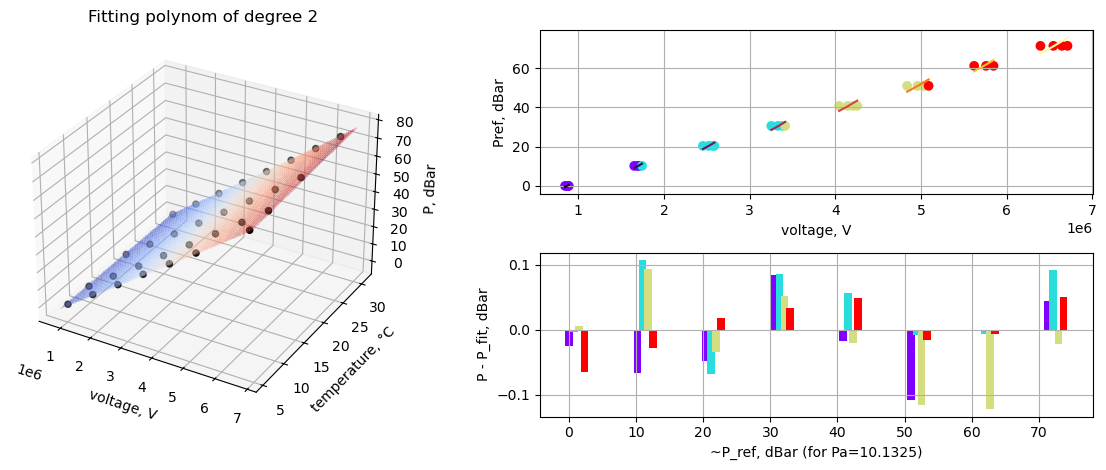

In [7]:
# Show plots
# %matplotlib inline  # is it realy changes something in juputerlab
fig = plt.figure(figsize=plt.figaspect(0.4))
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 4)  # , sharex=ax2 link x axis
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

# Plot result surface
u_min, u_max, t_min, t_max, P_min, P_max = np.min(u), np.max(u), np.min(t), np.max(t), np.min(y), np.max(y)
print(
    "; ".join(
        f"{var}(min,max): {v1:.3g}, {v2:.3g}"
        for var, v1, v2 in (("u", u_min, u_max), ("t", t_min, t_max), ("P", P_min, P_max))
    )
)
ptp_u, ptp_t, ptp_y = u_max - u_min, t_max - t_min, P_max - P_min
n = 50
X = np.linspace(u_min - ptp_u / n, u_max + ptp_u / n, n)
Y = np.linspace(t_min - ptp_t / n, t_max + ptp_t / n, n)
X, Y = np.meshgrid(X, Y)
Z_in = np.column_stack((X.ravel(), Y.ravel()))
Z = regr.predict(poly_model.fit_transform(Z_in)).reshape(X.shape)
surf = ax1.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.2)
ax1.scatter3D(*x.values.T, y, color="k")
ax1.set_xlabel("voltage, V")
ax1.set_ylabel("temperature, °C")
ax1.set_zlabel("P, dBar")  # pressure
ax1.set_title(f"Fitting polynom of degree {degree}")

# Plot predictions lines for each sub experiment in assumption that external values changes linear between fitting points
# experiment's colors
n_p = max(i_p) + 1
c_press = cm.inferno(np.linspace(0, 1, n_p))

shifts_temps = np.linspace(0, 1, int(round(i_p.size / n_p)))
c_temps = cm.rainbow(shifts_temps)[np.argsort(t[i_p == 0])]
# fitting points # Get y order. # addition has no effect if t sorted rev.
isort = np.argsort(i_p + 0.5 * (t_min - t) / ptp_t)
ax2.scatter(x["u"].values[isort], y[isort], c=c_temps[i_exp])  #np.tile(, (n_p, 1)) c_temps[i_exp]
# predictions
print("Errors of fit for experiments with different pressure and temperature:")
scale_bar_width = 1 / (2 * i_p.size)
for i, (c_exp, y_dif_cur) in enumerate(zip(c_press, ref_possible)):
    b_exp = i_p == i  # each t, °C for current Pdif
    x_exp = x[b_exp]
    y_exp = y[b_exp]
    # print(u_exp, t_exp)
    u_min, t_min, u_max, t_max, t_mean = *x_exp.min(), *x_exp.max(), x_exp["t"].mean()
    # print('u(min,max):', u_min, u_max, 't(min,max):', t_min, t_max)
    X = np.linspace(u_min, u_max, n)
    Y = np.linspace(t_min, t_max, n)
    Z_in = np.column_stack((X, Y))
    Z_in_tr = poly_model.fit_transform(Z_in)
    Z = regr.predict(Z_in_tr)
    Z_check = regr.intercept_ + (regr.coef_ * Z_in_tr).sum(axis=1)
    np.testing.assert_array_almost_equal(Z, Z_check)

    ax2.plot(X, Z, color=c_exp, label=f"{t_mean:.1f}±{(t_max - t_min) / 2:.1f}")
    z_diff = (y - y_pred)[b_exp]  # z_diff = y_exp - regr.predict(poly_model.fit_transform(x_exp))
    print(f"{y_dif_cur:.1f} dBar:", z_diff, "dBar")

# Plot residuals


ax3.bar(
    x=y_dif + shifts_temps[i_exp] * ptp_y * scale_bar_width*2,  #np.tile( - 0.1, n_p)
    height=(y - y_pred), # [isort]
    width=ptp_y * scale_bar_width,
    color=c_temps[i_exp],  #np.repeat(, n_p, axis=0) c_temps,  # , label=param
)

# # ax3.plot([u_min, u_max], z_diff, color=c_exp)
# ax3.bar(x=[u_min, u_max], height=z_diff, width=ptp_u/10, color=c_exp)
ax3.set_xlabel(f"~P_ref, dBar (for Pa={y_0})")
ax3.set_ylabel("P - P_fit, dBar")

ax2.set_xlabel("voltage, V")
ax2.set_ylabel("Pref, dBar")
# ax2.legend(title="mean t ±Δt °C")
ax2.grid()
ax3.grid()

plt.tight_layout()
plt.savefig(Path(path_in.parent / f"regression_residuals@{pid}.png"))
plt.show()